In [3]:
#Thêm thư viện
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np

MSE giữa x(n) và x’(n) (Z-transform): 1.5589379755497257


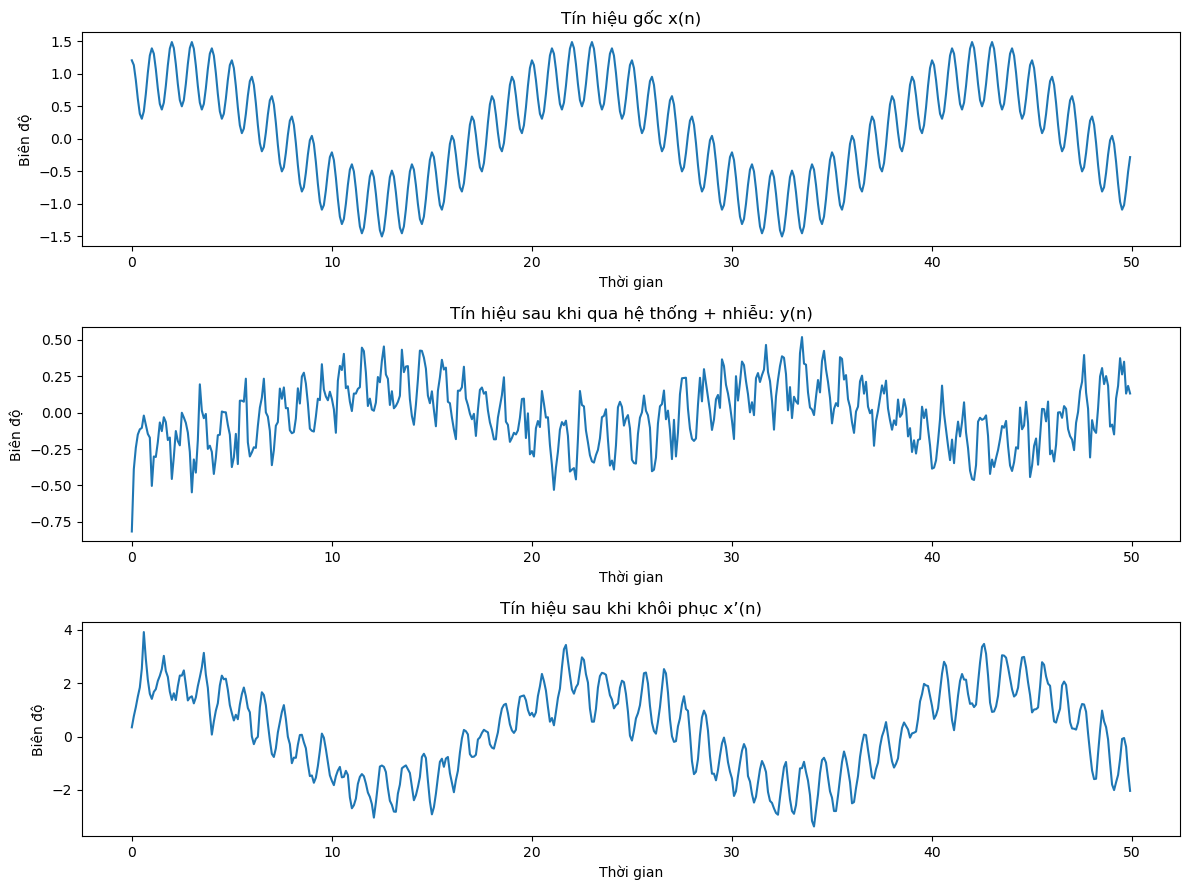

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Hàm Z-transform
def z_transform(x):
    w = np.arange(-2*np.pi, 2*np.pi, 4*np.pi/512)      # cho w đi từ -2pi đến 2pi, bước nhảy 4pi/512
    z = np.exp(1j * w) # z = e^(jw)
    Xz = np.zeros(len(z), dtype=complex)              # Khởi tạo Xz ban đầu có dạng 0+0j 
    for n in range(len(x)):
        Xz += x[n] * (z ** -n)                        # thực hiện công dồn tích giữa x(n) và z^(-n)
    return z, Xz                                      # giá trị trả về

# Hàm inverse Z-transform
def inverse_z_transform(Xz, N): # Xz là biến 
    w = np.arange(-2*np.pi, 2*np.pi, 4*np.pi/512) 
    z = np.exp(1j * w)
    x_rec = []                                        # khởi tạo mảng rỗng để lưu trữ tín hiệu đã được khôi phục
    for n in range(N):
        xn = (1 / (2 * np.pi)) * np.sum(Xz * z**(n) * (4*np.pi/512)) # nhân bước nhảy để xấp xỉ tích phân tổng rời rạc
        x_rec.append(np.real(xn))                     # chỉ lấy phần thực vì tín hiệu gốc là số thực 
                                                      # còn phần ảo là nhiễu nên chỉ lấy số thực để khôi phục cho đúng
    return np.array(x_rec)

# Tạo tín hiệu đầu vào
fs = 10  # tần số lấy mẫu
ts = 50  # thời gian lấy mẫu
t = np.linspace(0, ts, fs*ts, endpoint=False)        # trục thời gian

f1 = 0.05 
a1 = 1
phi_1 = np.pi / 4
s1 = a1 * np.sin(2*np.pi*f1*t + phi_1)

f2 = 1
a2 = 0.5
phi_2 = np.pi / 2
s2 = a2 * np.sin(2*np.pi*f2*t + phi_2)

x = s1 + s2  # tín hiệu đầu vào

# Hệ thống h(n) và nhiễu trắng
h = [0.5, -1, 0.3]
y = np.convolve(x, h, mode="same")
noise = 0.08 * np.random.randn(len(x)) # tạo nhiễu ngẫu nhiên 
y_noisy = y + noise

# Biến đổi Z
z, H = z_transform(h)
W = 1 / H
w_n = inverse_z_transform(W, fs * ts)

# Khôi phục tín hiệu x’(n) ≈ x(n)
x_rec = np.convolve(y_noisy, w_n, mode="same") 

# Vẽ kết quả
plt.figure(figsize=(12, 9))

plt.subplot(3, 1, 1)
plt.plot(t, x)
plt.title("Tín hiệu gốc x(n)")
plt.ylabel("Biên độ")
plt.xlabel("Thời gian")

plt.subplot(3, 1, 2)
plt.plot(t, y_noisy)
plt.title("Tín hiệu sau khi qua hệ thống + nhiễu: y(n)")
plt.ylabel("Biên độ")
plt.xlabel("Thời gian")

plt.subplot(3, 1, 3)
plt.plot(t, x_rec)
plt.title("Tín hiệu sau khi khôi phục x’(n)")
plt.ylabel("Biên độ")
plt.xlabel("Thời gian")

plt.tight_layout()




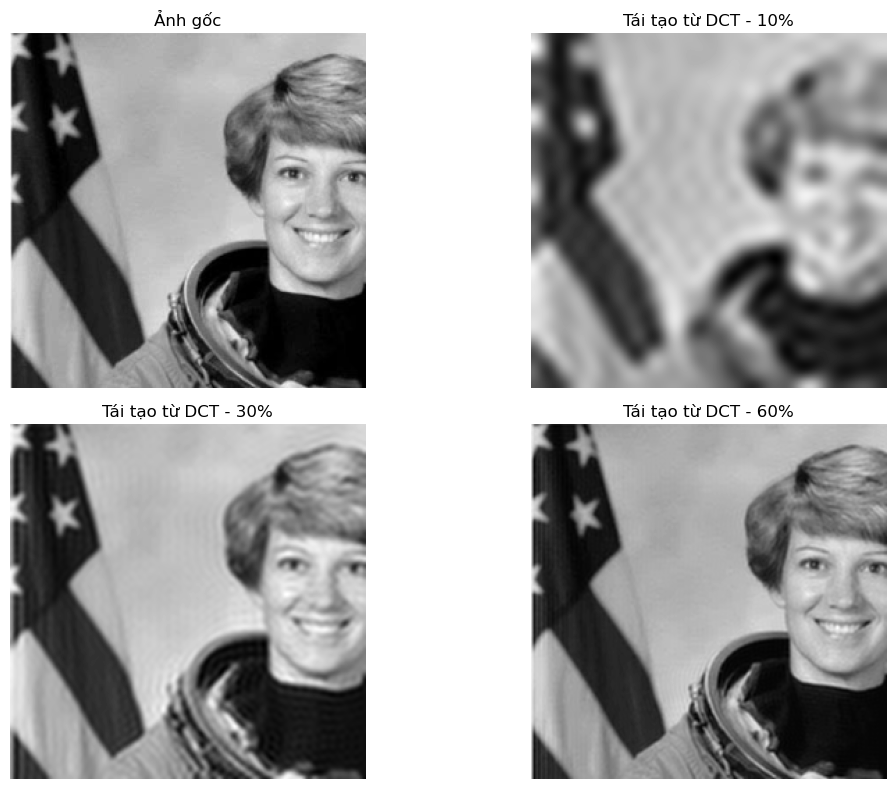

In [10]:
# Khai báo thư viện
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct        # Thư viện chứa hàm DCT và IDCT 1D/2D
from skimage.io import imread              # Thư viện dùng để đọc ảnh từ file
from skimage.color import rgb2gray         # Chuyển ảnh màu RGB sang ảnh xám (grayscale)
from skimage.transform import resize       # Thay đổi kích thước ảnh (chuẩn hóa kích thước ảnh đầu vào)


# Bước 1: Đọc ảnh gốc và chuẩn hóa
image = imread("anhgoc.jpg")
image = rgb2gray(image)                    # chuyển xám để giảm chiều dữ liệu, dễ phân tích
image = resize(image, (256, 256))          # tăng tính đồng nhất cho dễ xử lý
 
# Bước 2: Hàm DCT và IDCT 2 chiều
def dct2(a): # a biểu diễn cường độ sáng của ảnh xám
    return dct(dct(a.T, norm='ortho').T, norm='ortho') # DCT 2 chiều được thực hiện bằng cách áp dụng DCT 1 chiều lần lượt theo từng hàng và từng cột. 
                                                # Việc sử dụng norm='ortho' giúp chuẩn hóa kết quả, đảm bảo phép biến đổi và nghịch đảo là chính xác

def idct2(a):
    return idct(idct(a.T, norm='ortho').T, norm='ortho') # IDCT 2 chiều cũng tương tự
 
# Bước 3: Biến đổi DCT cho ảnh gốc
image_dct = dct2(image)

# Bước 4: Hàm giữ lại tần số thấp theo mức phần trăm
def reconstruct_from_dct(dct_img, retain_fraction):    # ảnh DCT và mức phần trăm khôi phục
    rows, cols = dct_img.shape                         # lấy kích thước của ảnh
    mask = np.zeros_like(dct_img)                      # tạo 1 mặt nạ có cùng kích thước ảnh DCT nhưng loại hết các tần số (toàn bộ 0)
    mask[:int(rows * retain_fraction), :int(cols * retain_fraction)] = 1 # bật lên 1 ở vị trí góc trên bên trái vì đây là nơi chứa tần số thấp
    dct_filtered = dct_img * mask                      # nhân ảnh DCT với mask để ảnh DCT chỉ có tần số thấp
    return idct2(dct_filtered)                         # tái tạo ảnh ở miền không gian, lúc này ảnh đã bị mờ
                     
# Bước 5: Tái tạo ảnh với 3 mức
recon_10 = reconstruct_from_dct(image_dct, 0.1)
recon_30 = reconstruct_from_dct(image_dct, 0.3)
recon_60 = reconstruct_from_dct(image_dct, 0.6)

# Bước 6: Hiển thị
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray') # in ra ảnh
plt.title("Ảnh gốc")
plt.axis('off')   # ẩn đi trục x, y

plt.subplot(2, 2, 2)
plt.imshow(recon_10, cmap='gray')
plt.title("Tái tạo từ DCT - 10%")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(recon_30, cmap='gray')
plt.title("Tái tạo từ DCT - 30%")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(recon_60, cmap='gray') # colourmap = gray:  hiển thị đúng màu xám
plt.title("Tái tạo từ DCT - 60%")
plt.axis('off')

plt.tight_layout()
plt.show()


In [14]:

import numpy as np
import matplotlib.pyplot as plt


#  Hàm tính MSE
def calculate_mse(signal1, signal2):
    """
    Tính sai số bình phương trung bình (MSE) giữa 2 tín hiệu/ảnh
    """
    signal1 = np.array(signal1)
    signal2 = np.array(signal2)

    if signal1.shape != signal2.shape:
        print("Hai mảng không cùng kích thước")

    mse = np.mean((signal1 - signal2) ** 2)
    return mse

# ===============================
# TÍNH MSE GIỮA TÍN HIỆU x(n) & x’(n)
# ===============================

mse_z = calculate_mse(x, x_rec)
print("MSE giữa x(n) và x’(n) (Z-transform):", mse_z)


# ===============================
# TÍNH MSE GIỮA ẢNH GỐC VÀ ẢNH DCT TÁI TẠO
# ===============================


mse_10 = calculate_mse(image, recon_10)
mse_30 = calculate_mse(image, recon_30)
mse_60 = calculate_mse(image, recon_60)
print("\nMSE giữa ảnh gốc và ảnh 10%:", mse_10)
print("MSE giữa ảnh gốc và ảnh 30%:", mse_30)
print("MSE giữa ảnh gốc và ảnh 60%:", mse_60)


MSE giữa x(n) và x’(n) (Z-transform): 1.5589379755497257

MSE giữa ảnh gốc và ảnh 10%: 0.005745645383983517
MSE giữa ảnh gốc và ảnh 30%: 0.0010742993831898142
MSE giữa ảnh gốc và ảnh 60%: 0.00014442668966819824
